# Cross-Dialect Evaluation
Each of the 4 trained models is tested on all 4 input dialects — including ones it was never trained on.

**If a model truly learned PDE structure** (not just surface patterns), it should partially generalize across dialects.  
**If it only memorized its training dialect**, off-diagonal accuracy will collapse.

Result: a 4×4 accuracy matrix where diagonal = in-dialect, off-diagonal = cross-dialect generalization.

## 1. Setup

In [8]:
import json
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings('ignore')

from collections import Counter
from sklearn.model_selection import train_test_split
from transformers import T5Tokenizer, T5ForConditionalGeneration
import evaluate

if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'
print(f'Device: {device}')

Device: mps


In [9]:
from pathlib import Path

DIALECTS = ['natural', 'latex', 'prefix', 'postfix']
PROJECT_ROOT = Path.cwd()
DATASET_PATH = PROJECT_ROOT / 'varied_data_generation' / 'dataset.jsonl'
MODEL_DIR_CANDIDATES = [
    PROJECT_ROOT / 'models',
    PROJECT_ROOT / 'outputs' / 't5_dialects' / 'instance',
]
MODELS_DIR = next((path for path in MODEL_DIR_CANDIDATES if path.exists()), MODEL_DIR_CANDIDATES[0])
SEED = 42
MAX_INPUT_LENGTH  = 256
MAX_OUTPUT_LENGTH = 256

REASONING_KEYWORDS = {
    'Heat'     : ['first-order time', 'second-order spatial', 'diffus'],
    'Wave'     : ['second-order time', 'wave', 'speed'],
    'Burgers'  : ['nonlinear', 'convect', 'viscosit', 'u*u_x'],
    'Laplace'  : ['steady', 'no time', 'equilibrium', 'u_xx'],
    'Advection': ['transport', 'advect', 'first-order'],
}
print(f'Config ready. DATASET_PATH={DATASET_PATH}')
print(f'MODELS_DIR={MODELS_DIR}')
if not DATASET_PATH.exists():
    raise FileNotFoundError(f'Dataset not found: {DATASET_PATH}')
if not MODELS_DIR.exists():
    print('Warning: model directory does not exist yet. Update MODELS_DIR or train/export checkpoints first.')

Config ready. DATASET_PATH=/Users/chenyixin/Documents/CSCI5541/group project/Nlp-group-final-project/varied_data_generation/dataset.jsonl
MODELS_DIR=/Users/chenyixin/Documents/CSCI5541/group project/Nlp-group-final-project/models


## 2. Load Test Set (same split as training)

In [10]:
all_data = []
with open(DATASET_PATH) as f:
    for line in f:
        all_data.append(json.loads(line.strip()))

# Reproduce exact same split from training notebook
train_val, test_data = train_test_split(
    all_data,
    test_size=0.1,
    stratify=[d['family'] for d in all_data],
    random_state=SEED
)
print(f'Test set: {len(test_data)} instances')
print('Family distribution:', dict(Counter(d['family'] for d in test_data)))

Test set: 1000 instances
Family distribution: {'Burgers': 200, 'Heat': 200, 'Laplace': 200, 'Advection': 200, 'Wave': 200}


## 3. Helper Functions

In [11]:
def get_best_checkpoint(dialect):
    model_dir = Path(MODELS_DIR) / dialect
    if not model_dir.exists():
        raise FileNotFoundError(
            f'No checkpoint directory found for dialect={dialect!r} at {model_dir}. '
            'Update MODELS_DIR or train/export the dialect checkpoints first.'
        )
    checkpoints = sorted(
        [path for path in model_dir.iterdir() if path.name.startswith('checkpoint-')],
        key=lambda path: int(path.name.split('-')[-1]),
    )
    if not checkpoints:
        raise FileNotFoundError(f'No checkpoint-* directories found under {model_dir}')
    return str(checkpoints[-1])


def parse_prediction(pred):
    result = {'family': None, 'operators': [], 'reasoning': ''}
    try:
        for part in pred.split(' | '):
            part = part.strip()
            if part.startswith('family:'):
                result['family'] = part.replace('family:', '').strip()
            elif part.startswith('operators:'):
                ops = part.replace('operators:', '').strip()
                result['operators'] = [o.strip() for o in ops.split(',') if o.strip()]
            elif part.startswith('reasoning:'):
                result['reasoning'] = part.replace('reasoning:', '').strip()
    except Exception:
        pass
    return result


def is_reasoning_correct(family, reasoning_text):
    keywords = REASONING_KEYWORDS.get(family, [])
    return any(kw.lower() in reasoning_text.lower() for kw in keywords)


def run_inference(model, tokenizer, test_data, input_dialect):
    """Run model on test_data using input_dialect as input. Returns raw prediction strings."""
    model.eval()
    model.to('cpu')   # CPU to avoid MPS beam search bug
    predictions = []

    for i in range(0, len(test_data), 16):
        batch = test_data[i:i+16]
        inputs_text = [d['dialects'][input_dialect] for d in batch]
        enc = tokenizer(
            inputs_text,
            return_tensors='pt',
            max_length=MAX_INPUT_LENGTH,
            truncation=True,
            padding=True,
        )
        with torch.no_grad():
            out = model.generate(**enc, max_new_tokens=MAX_OUTPUT_LENGTH)
        predictions.extend(tokenizer.batch_decode(out, skip_special_tokens=True))

    return predictions


def compute_accuracy_and_trash(test_data, predictions_raw):
    parsed = [parse_prediction(p) for p in predictions_raw]

    correct = sum(
        1 for d, p in zip(test_data, parsed)
        if p['family'] and p['family'].lower() == d['family'].lower()
    )
    family_acc = correct / len(test_data)

    trash_count = sum(
        1 for d, p in zip(test_data, parsed)
        if p['family'] and p['family'].lower() == d['family'].lower()
        and not is_reasoning_correct(d['family'], p['reasoning'])
    )
    trash_score = trash_count / len(test_data)

    return family_acc, trash_score


print('Helpers ready.')

Helpers ready.


## 4. Build 4×4 Matrix

In [12]:
# Rows = model trained on, Cols = tested on
accuracy_matrix    = pd.DataFrame(index=DIALECTS, columns=DIALECTS, dtype=float)
trash_matrix       = pd.DataFrame(index=DIALECTS, columns=DIALECTS, dtype=float)

tokenizer = T5Tokenizer.from_pretrained('t5-small')

for train_dialect in DIALECTS:
    print(f'\nLoading model trained on: {train_dialect.upper()}')
    checkpoint = get_best_checkpoint(train_dialect)
    model = T5ForConditionalGeneration.from_pretrained(checkpoint)

    for test_dialect in DIALECTS:
        print(f'  Testing on: {test_dialect}...', end=' ')
        preds = run_inference(model, tokenizer, test_data, test_dialect)
        acc, trash = compute_accuracy_and_trash(test_data, preds)
        accuracy_matrix.loc[train_dialect, test_dialect] = round(acc * 100, 1)
        trash_matrix.loc[train_dialect, test_dialect]    = round(trash * 100, 1)
        print(f'Acc={acc:.1%}  Trash={trash:.1%}')

    del model

print('\nDone!')

ImportError: 
T5Tokenizer requires the SentencePiece library but it was not found in your environment. Check out the instructions on the
installation page of its repo: https://github.com/google/sentencepiece#installation and follow the ones
that match your environment. Please note that you may need to restart your runtime after installation.


## 5. Results Tables

In [ ]:
print('=== FAMILY ACCURACY (%) — rows=trained on, cols=tested on ===')
print(accuracy_matrix.to_string())
print()
print('=== TRASH SCORE (%) — rows=trained on, cols=tested on ===')
print(trash_matrix.to_string())

# Save
accuracy_matrix.to_csv('cross_dialect_accuracy.csv')
trash_matrix.to_csv('cross_dialect_trash.csv')
print('\nSaved to CSV.')

=== FAMILY ACCURACY (%) — rows=trained on, cols=tested on ===
         natural  latex  prefix  postfix
natural    100.0   20.0    20.0     20.0
latex        0.0  100.0     0.0      0.0
prefix       0.0    0.0   100.0     50.7
postfix      3.9   44.8    49.5    100.0

=== TRASH SCORE (%) — rows=trained on, cols=tested on ===
         natural  latex  prefix  postfix
natural      0.0    0.0     0.0      0.0
latex        0.0    0.0     0.0      0.0
prefix       0.0    0.0     0.0      0.0
postfix      0.0   20.0    20.0      0.0

Saved to CSV.


## 6. Heatmap Visualisation

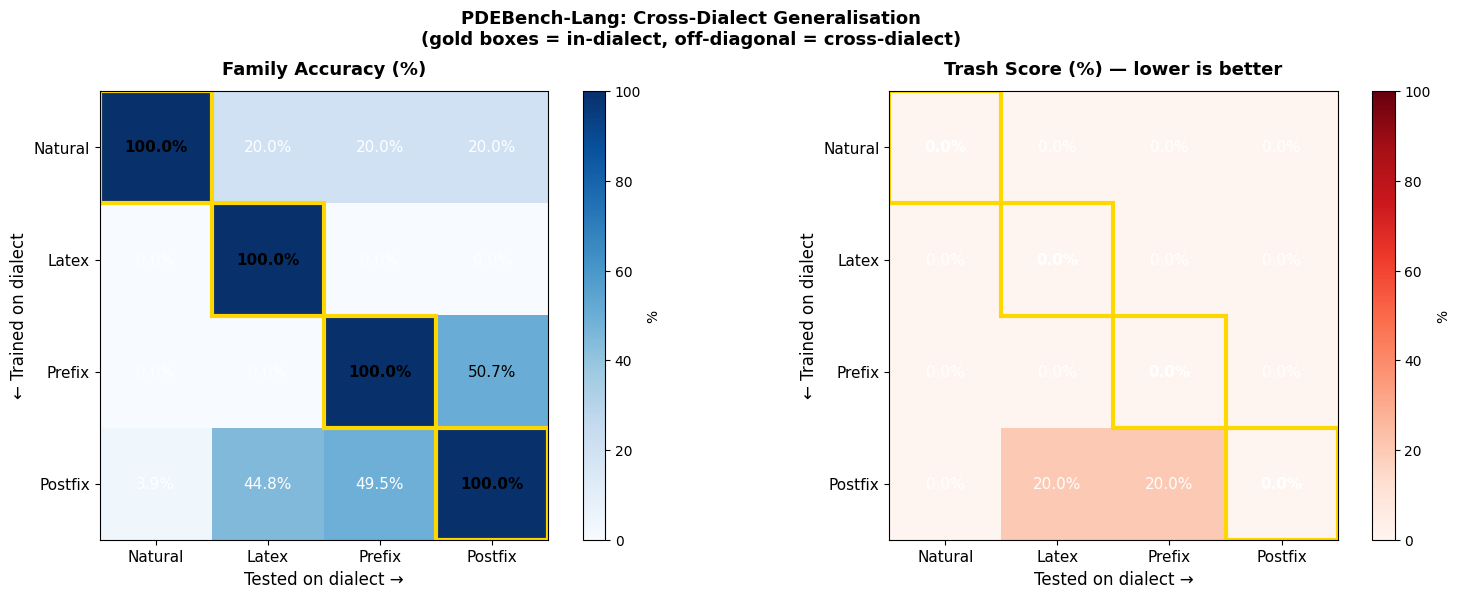

Saved to cross_dialect_heatmap.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

def plot_heatmap(ax, matrix, title, cmap, fmt='.1f'):
    data = matrix.values.astype(float)
    im = ax.imshow(data, cmap=cmap, vmin=0, vmax=100)
    ax.set_xticks(range(len(DIALECTS)))
    ax.set_yticks(range(len(DIALECTS)))
    ax.set_xticklabels([d.capitalize() for d in DIALECTS], fontsize=11)
    ax.set_yticklabels([d.capitalize() for d in DIALECTS], fontsize=11)
    ax.set_xlabel('Tested on dialect →', fontsize=12)
    ax.set_ylabel('← Trained on dialect', fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=12)
    for i in range(len(DIALECTS)):
        for j in range(len(DIALECTS)):
            val = data[i, j]
            color = 'white' if val < 50 else 'black'
            ax.text(j, i, f'{val:{fmt}}%',
                    ha='center', va='center', fontsize=11,
                    fontweight='bold' if i == j else 'normal',
                    color=color)
    # Highlight diagonal
    for k in range(len(DIALECTS)):
        ax.add_patch(plt.Rectangle((k-0.5, k-0.5), 1, 1,
                     fill=False, edgecolor='gold', linewidth=3))
    plt.colorbar(im, ax=ax, label='%')

plot_heatmap(axes[0], accuracy_matrix, 'Family Accuracy (%)', 'Blues')
plot_heatmap(axes[1], trash_matrix,    'Trash Score (%) — lower is better', 'Reds')

plt.suptitle('PDEBench-Lang: Cross-Dialect Generalisation\n(gold boxes = in-dialect, off-diagonal = cross-dialect)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cross_dialect_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to cross_dialect_heatmap.png')

## 7. Key Findings

In [ ]:
print('=== KEY FINDINGS ===')

# Best cross-dialect generaliser
off_diag_acc = {}
for train_d in DIALECTS:
    scores = [accuracy_matrix.loc[train_d, test_d]
              for test_d in DIALECTS if test_d != train_d]
    off_diag_acc[train_d] = np.mean(scores)

best  = max(off_diag_acc, key=off_diag_acc.get)
worst = min(off_diag_acc, key=off_diag_acc.get)

print(f'\nBest cross-dialect generaliser  : {best.upper()} (avg off-diagonal acc = {off_diag_acc[best]:.1f}%)')
print(f'Worst cross-dialect generaliser : {worst.upper()} (avg off-diagonal acc = {off_diag_acc[worst]:.1f}%)')

print(f'\nHypothesis check (LaTeX generalises better than Postfix):')
if off_diag_acc['latex'] > off_diag_acc['postfix']:
    print(f'  SUPPORTED — LaTeX={off_diag_acc["latex"]:.1f}% > Postfix={off_diag_acc["postfix"]:.1f}%')
else:
    print(f'  NOT SUPPORTED — LaTeX={off_diag_acc["latex"]:.1f}% <= Postfix={off_diag_acc["postfix"]:.1f}%')

print(f'\nNatural→Postfix accuracy : {accuracy_matrix.loc["natural", "postfix"]:.1f}%')
print(f'Postfix→Natural accuracy : {accuracy_matrix.loc["postfix", "natural"]:.1f}%')
print(f'Latex→Postfix accuracy   : {accuracy_matrix.loc["latex", "postfix"]:.1f}%')

=== KEY FINDINGS ===

Best cross-dialect generaliser  : POSTFIX (avg off-diagonal acc = 32.7%)
Worst cross-dialect generaliser : LATEX (avg off-diagonal acc = 0.0%)

Hypothesis check (LaTeX generalises better than Postfix):
  NOT SUPPORTED — LaTeX=0.0% <= Postfix=32.7%

Natural→Postfix accuracy : 20.0%
Postfix→Natural accuracy : 3.9%
Latex→Postfix accuracy   : 0.0%
